# 2.45 GHz patch antenna: design diary

We calculate the starting dimensions for a rectangular patch on FR4, $\varepsilon_r=4.4$ and thickness $h=1.57$ mm. We want it resonant at 2.45 GHz.

First we calculate the width, then the effective permittivity and edge extension. The edge extension accounts for fringing, so we subtract it from both ends to get the physical patch length:

$$W=\frac{c}{2f_0}\sqrt{\frac{2}{\varepsilon_r+1}}$$
$$\varepsilon_\mathrm{eff}=\frac{\varepsilon_r+1}{2}+\frac{\varepsilon_r-1}{2}\left(1+12\frac{h}{W}\right)^{-1/2}$$
$$\Delta L=0.412h\frac{(\varepsilon_\mathrm{eff}+0.3)(W/h+0.264)}{(\varepsilon_\mathrm{eff}-0.258)(W/h+0.8)}$$
$$L=\frac{c}{2f_0\sqrt{\varepsilon_\mathrm{eff}}}-2\Delta L$$

Plugging them into the equation:

In [1]:
import csv
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (9, 4)
f0, er, h, c = 2.45e9, 4.4, 1.57e-3, 3e8
W = c / (2*f0) * np.sqrt(2/(er+1))
e_eff = (er+1)/2 + (er-1)/2 * (1+12*h/W)**(-0.5)
dL = 0.412*h * ((e_eff+0.3)*(W/h+0.264)) / ((e_eff-0.258)*(W/h+0.8))
L = c/(2*f0*np.sqrt(e_eff)) - 2*dL
print(f'Patch width x length: {W*1e3:.5f} mm x {L*1e3:.5f} mm')
print(f'Effective permittivity: {e_eff:.4f}; edge extension: {dL*1e3:.4f} mm')

def read_csv(name):
    with open(name, newline='') as f:
        rows = list(csv.DictReader(f))
    return {key: np.array([float(row[key]) for row in rows]) for key in rows[0]}

F, S = 'Freq [GHz]', 'dB(S(1,1)) []'
def s11_axes(ax, title):
    ax.axvline(2.45, color='black', ls=':', lw=1, label='2.45 GHz target')
    ax.axhline(-10, color='gray', ls='--', lw=1)
    ax.set(xlabel='Frequency (GHz)', ylabel='S11 (dB)', title=title,
           xlim=(2.2, 2.65), ylim=(-40, 0))
    ax.legend(fontsize=9)

def plot_sweep(name, parameter, symbol, title):
    data = read_csv(name)
    fig, ax = plt.subplots()
    for value in np.unique(data[parameter]):
        mask = data[parameter] == value
        ax.plot(data[F][mask], data[S][mask], label=f'{symbol} = {value:g} mm')
    s11_axes(ax, title)
    fig.tight_layout()
    plt.show()
    return data

Patch width x length: 37.26004 mm x 28.84054 mm
Effective permittivity: 4.0854; edge extension: 0.7249 mm


## First try

The calculation gives a patch width of 37.26004 mm and length of 28.84054 mm. We start with these dimensions in HFSS, a feed width of about 3 mm and an inset depth of 5 mm. The saved run uses a 3.33 mm feed. We first check S11 to see where the patch resonates and how well it is matched.

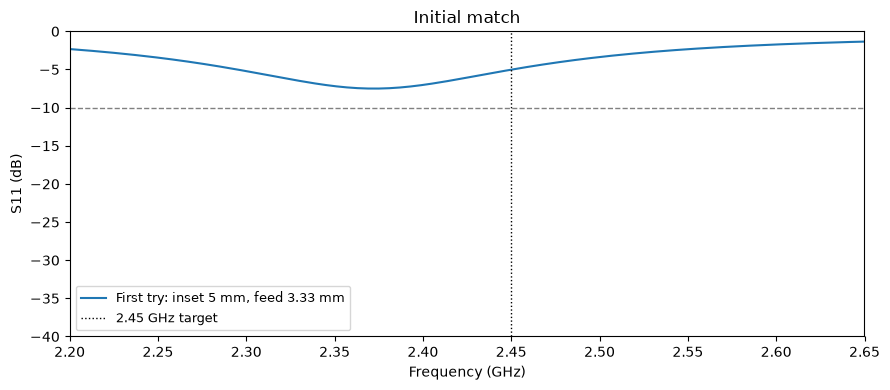

In [2]:
first = read_csv('csv/s11_first_try_v2.csv')
fig, ax = plt.subplots()
ax.plot(first[F], first[S], label='First try: inset 5 mm, feed 3.33 mm')
s11_axes(ax, 'Initial match')
fig.tight_layout()
plt.show()

Pretty bad match, the dip only reaches -7.50 dB at 2.372 GHz, and S11 is -5.03 dB at our target. The calculated dimensions give us a starting point, but the resonance is too low and the feed needs tuning. We tackle the match first.

## Inset and feed sweeps

We first adjust the inset depth and feed width to improve the match. From the design notes, increasing the inset depth helps, but its effect is smaller than changing the feed width. We choose an inset depth of 7.5 mm, then compare feed widths from 1.5 to 4.5 mm below. There is no saved graph for the inset sweep.

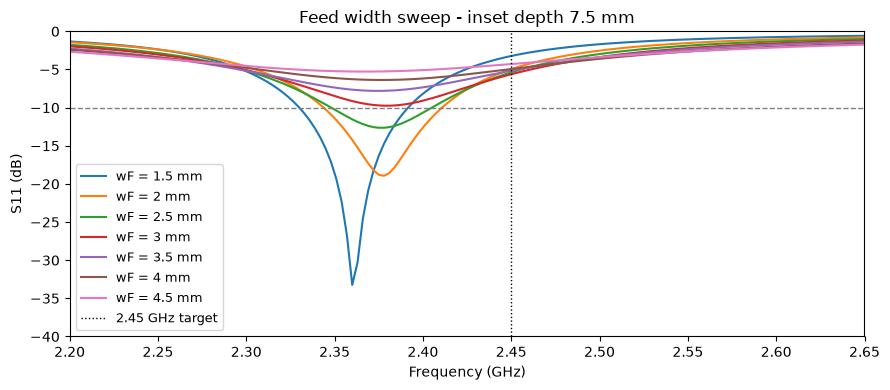

In [3]:
feed = plot_sweep('csv/s11_wF_sweep.csv', 'wF [mm]', 'wF',
                  'Feed width sweep - inset depth 7.5 mm')

Reducing the feed width makes the dip much deeper. At 1.5 mm it reaches -33.24 dB, the best result in this sweep, so we keep that width and the 7.5 mm inset. The dip is still at 2.360 GHz, to solve the match at 2.45 GHz we'll adjust the patch length.

## Patch length sweep

The feed sweep gives us a good dip, but at the wrong frequency. We now shorten the patch to move the resonance up, keeping the 1.5 mm feed and 7.5 mm inset. We sweep the patch length from 27.5 to 28.0 mm to find the value that puts the dip at 2.45 GHz.

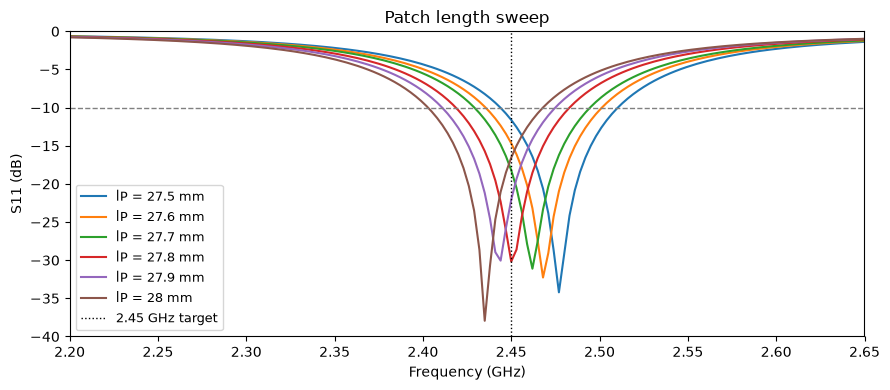

In [4]:
length = plot_sweep('csv/s11_lP_sweep.csv', 'lP [mm]', 'lP', 'Patch length sweep')

The sweep follows the expected trend: shorter patches resonate at higher frequencies. With a length of 27.8 mm, the dip is bang on 2.45 GHz at -30.17 dB. Some other lengths give deeper dips, but away from our target, so we choose 27.8 mm and recheck the feed width.

## Final feed width sweep

The frequency is now right, but the earlier feed sweep gave its best result at the smallest width tested. Let's go below 1.5 mm and see whether the match keeps improving. With the patch length fixed at 27.8 mm, we sweep the feed from 0.5 to 2.0 mm.

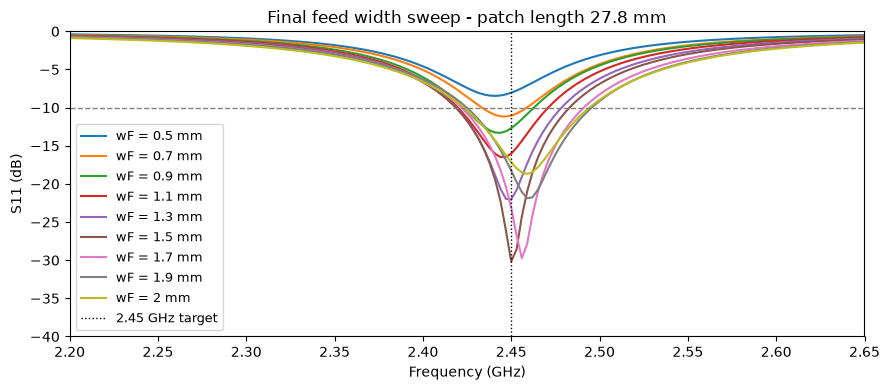

Chosen feed: 1.5 mm; S11 minimum: -30.17 dB at 2.450 GHz


In [5]:
final = plot_sweep('csv/s_wF_param_sweep.csv', 'wF [mm]', 'wF',
                   'Final feed width sweep - patch length 27.8 mm')
mask = np.isclose(final['wF [mm]'], 1.5)
f_final, s_final = final[F][mask], final[S][mask]
i = np.argmin(s_final)
print(f'Chosen feed: 1.5 mm; S11 minimum: {s_final[i]:.2f} dB at {f_final[i]:.3f} GHz')

Turns out 1.5 mm is still the best feed width at 2.45 GHz. Narrowing it to 1.3 mm gives -22.02 dB, while widening it to 1.7 mm gives -23.13 dB at the target and moves the dip up to 2.456 GHz. Neither improves on -30.17 dB, so we keep the 1.5 mm feed and stop tuning the dimensions.

## Final match

We check the chosen design against both S11 and input impedance. For a good match at 2.45 GHz, we want the resistance close to 50 ohms and the reactance close to zero. The impedance plot also includes the result before shortening the patch, so we can see what the length adjustment changed.

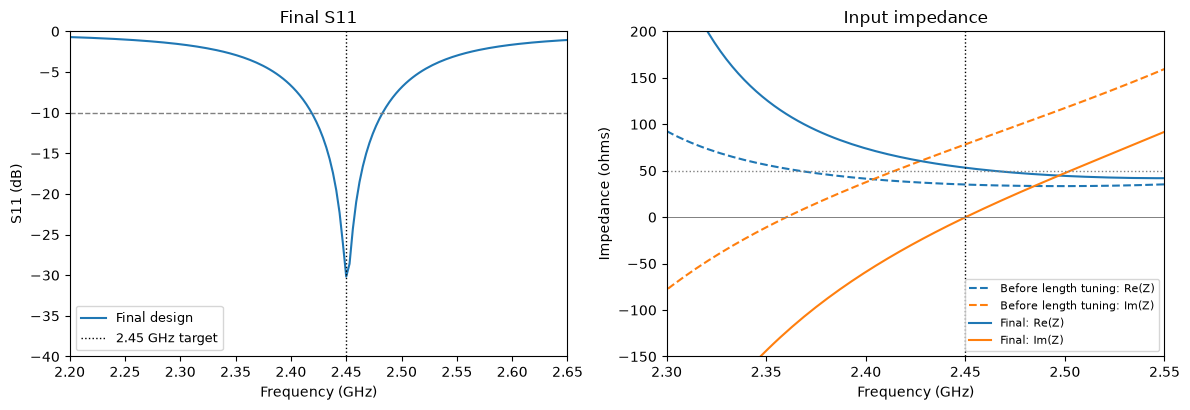

At 2.450 GHz: Z = 53.20 -0.14j ohms


In [6]:
before = read_csv('csv/z_wf_sweep.csv')
after = read_csv('csv/z_after_setting_27_8_mm.csv')
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(f_final, s_final, label='Final design')
s11_axes(axes[0], 'Final S11')
for data, style, stage in [(before, '--', 'Before length tuning'), (after, '-', 'Final')]:
    axes[1].plot(data[F], data['re(Z(1,1)) []'], style, color='tab:blue', label=f'{stage}: Re(Z)')
    axes[1].plot(data[F], data['im(Z(1,1)) []'], style, color='tab:orange', label=f'{stage}: Im(Z)')
axes[1].axvline(2.45, color='black', ls=':', lw=1)
axes[1].axhline(50, color='gray', ls=':', lw=1)
axes[1].axhline(0, color='gray', lw=0.7)
axes[1].set(xlabel='Frequency (GHz)', ylabel='Impedance (ohms)',
            title='Input impedance', xlim=(2.3, 2.55), ylim=(-150, 200))
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()
i = np.argmin(abs(after[F]-2.45))
print(f"At {after[F][i]:.3f} GHz: Z = {after['re(Z(1,1)) []'][i]:.2f} {after['im(Z(1,1)) []'][i]:+.2f}j ohms")

At 2.45 GHz, the impedance changes from $35.09+j78.33\ \Omega$ before length tuning to $53.20-j0.14\ \Omega$ in the final design. The reactance is now almost zero and the resistance is close to 50 ohms, consistent with the -30.17 dB S11 dip. The match is where we want it; next we check the radiation pattern.

## Radiation pattern

With the match sorted, we check where the antenna radiates at 2.45 GHz. We plot the saved $\phi=0^\circ$ gain cut, looking for a main beam normal to the patch and less radiation behind it.

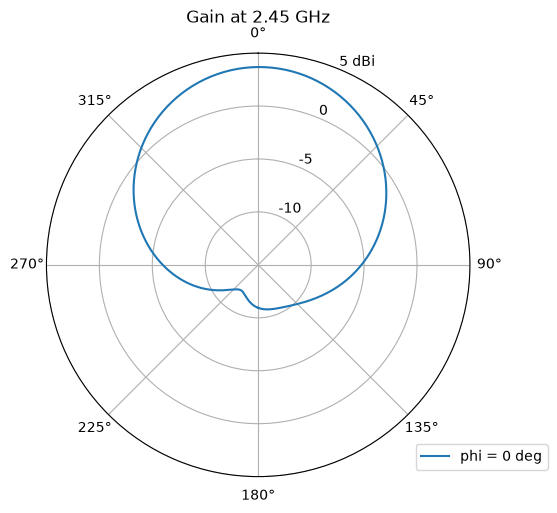

In [7]:
pattern = read_csv('csv/radiation_pattern_final_antenna.csv')
theta = np.deg2rad(pattern['Theta [deg]'])
gain = pattern['dB(GainTotal) []']
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(6, 5.5))
ax.plot(theta, gain, color='tab:blue', label='phi = 0 deg')
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_ylim(-15, 5)
ax.set_yticks([-15, -10, -5, 0, 5])
ax.set_yticklabels(['-15', '-10', '-5', '0', '5 dBi'])
ax.set_title('Gain at 2.45 GHz', pad=22)
ax.legend(loc='lower right', bbox_to_anchor=(1.2, 0))
plt.show()

The main beam points out from the patch, with much less gain behind it. The peak in this cut is 3.68 dBi, so the shape looks as expected for this design. We then check the 3D pattern to see whether the same behaviour holds beyond this single cut.

## 3D pattern

The cut shows one plane through the radiation pattern. We now look at the full 3D export to check the beam shape around the patch. This export is directivity rather than gain; the surface radius shows normalized linear directivity.

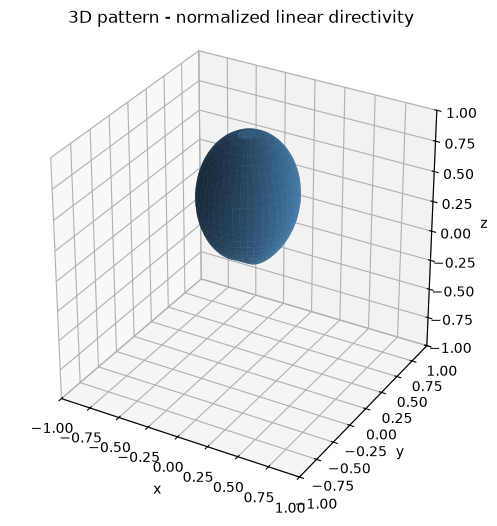

In [8]:
pattern3d = read_csv('csv/3d_pattern_final.csv')
# Sort by theta, then phi, to build the angular grid.
order = np.lexsort((pattern3d['Phi[deg]'], pattern3d['Theta[deg]']))
n_phi = len(np.unique(pattern3d['Phi[deg]']))
phi = np.deg2rad(pattern3d['Phi[deg]'][order].reshape(-1, n_phi))
theta = np.deg2rad(pattern3d['Theta[deg]'][order].reshape(-1, n_phi))
D = pattern3d['dB(DirTotal)'][order].reshape(-1, n_phi)
r = 10**((D-D.max())/10)  # Normalized linear directivity
x = r*np.sin(theta)*np.cos(phi)
y = r*np.sin(theta)*np.sin(phi)
z = r*np.cos(theta)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x, y, z, color='steelblue', alpha=0.9)
ax.set(xlabel='x', ylabel='y', zlabel='z',
       title='3D pattern - normalized linear directivity',
       xlim=(-1, 1), ylim=(-1, 1), zlim=(-1, 1))
ax.set_box_aspect((1, 1, 1))
plt.show()

The full pattern shows a broad main beam above the patch and weaker radiation behind it, consistent with the 2D cut. Peak directivity is 6.42 dBi. That is a different quantity from the 3.68 dBi gain in the previous plot, so we keep the two results separate. With the beam shape looking right and the match centred on 2.45 GHz, we keep this design.

## Final design

We keep the calculated patch width and use the tuned length, feed width and inset depth:

| Parameter | Value |
|---|---:|
| Substrate | FR4, $\varepsilon_r=4.4$ |
| Substrate thickness | 1.57 mm |
| Patch width | 37.26004 mm |
| Patch length | 27.8 mm |
| Feed width | 1.5 mm |
| Inset depth | 7.5 mm |
| S11 at 2.45 GHz | -30.17 dB |